In [1]:
import igraph as ig
import networkx as nx
import csv
import pandas as pd
import dask.dataframe as dd 
import matplotlib.pyplot as plt


/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [11]:
# App Name
# app_name = "montage-pegasus-2mass-2deg-4node" #cosmoflow cm1
# app_name = "1000_genome_pegasus_node_16"
# app_name = "cm1"
# app_name = "deepspeed-dlio-step100"
# app_name = "deepspeed-dlio-scr-step100"
app_name = "bert"
# app_name = "unet3d"
# app_name = "resnet50"
cp_dir = "/p/lustre3/pandey2/logs/Results_Checkpoint/dataflow/"+app_name+"/"

In [12]:
fhash_dir = "/p/lustre3/pandey2/logs/Results_Checkpoint/fhash/"+app_name+"/*.parquet"
fhash = dd.read_parquet(fhash_dir)
def getFilename(hash_value, fhash_df):
    result = fhash_df.query(f"hash == '{hash_value}'").compute()
    return result['name'].values

In [13]:
# Step 1: Level 3 Analysis
# create nx graph from original Networks


# Read the CSV file
df1 = pd.read_csv(cp_dir+"l3.csv", header=None, delimiter=" ", names=['src', 'dest'])
G3 = nx.DiGraph()
edge_list = list(zip(df1['src'], df1['dest']))
G3.add_edges_from(edge_list)


In [14]:
df1.head()

,src,dest
0,corona197,5308
1,corona197,42507
2,corona197,50977
3,corona197,19108
4,corona197,29107


In [8]:
getFilename('1.8128740601322631e+19',fhash)

<ArrowStringArray>
['/dev/infiniband/rdma_cm']
Length: 1, dtype: string

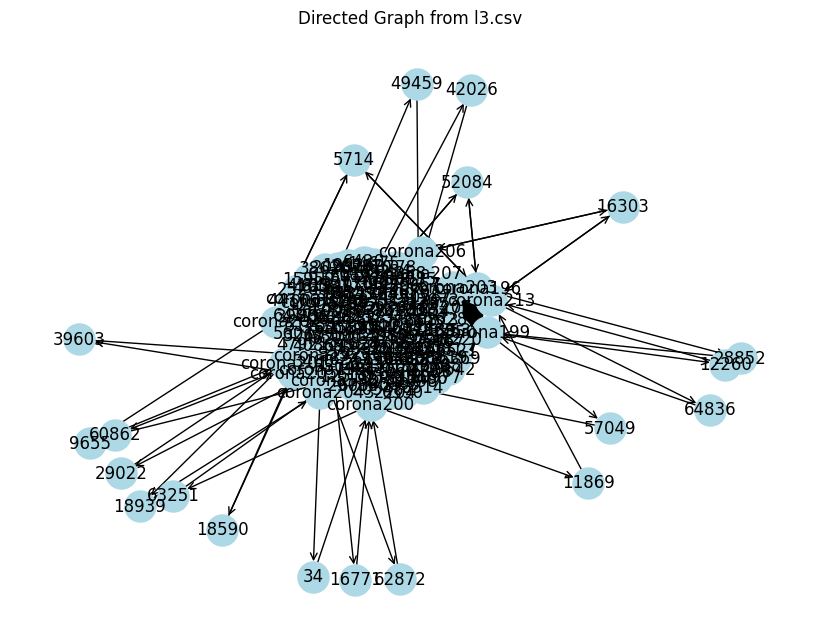

In [15]:

# Draw the graph with labels and arrows
plt.figure(figsize=(8, 6))  # Set figure size
pos = nx.spring_layout(G3)  # Layout for node positions

nx.draw(G3, pos, with_labels=True, node_size=500, node_color='lightblue', 
        arrows=True, arrowstyle='->', arrowsize=12)

plt.title("Directed Graph from l3.csv")
plt.axis('off')  # Hide axis
plt.show()

In [17]:
fhash.head()

,hash,name,pid,tid,hhash,mount_point
0,10048.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
1,10076.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
2,10189.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
3,1020.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2
4,10302.0,/usr/WS2/haridev/iopp/venvs/scr_dlio_env/lib/p...,3874420,3874420,<NA>,/usr/WS2


In [22]:
# getFilename('1.8128740601322631e+19',fhash) #resnet
# getFilename('1.8128740601322631e+19',fhash) #genome
getFilename('39603.0',fhash)

<ArrowStringArray>
['/proc/3874427/io']
Length: 1, dtype: string

In [ ]:
# Question What is this file?
# Total number of access in this file?
# total I/O size request in this size (read / write)

In [55]:

# Step 2: Level 1 and 2 # per node basis
# read parquet file groupby hostname and do analysis in each group
df2 = dd.read_parquet(cp_dir+"lvl1/*.parquet")
df2.compute()

,hostname,pid,fhash,ts
0,corona198,1447579,1.000160077285259e+19,6891966977
1,corona198,1447585,1.0002122491058502e+19,452051123
2,corona198,1447584,1.0002627534595666e+19,6855188916
3,corona198,1447585,1.000313961871544e+19,8225930628
4,corona198,1447581,1.000325340882533e+19,559936875
...,...,...,...,...
26043,corona201,2953266,9.995606683497929e+18,5027515092
26044,corona201,2953266,9.99716537952927e+18,5934397296
26045,corona201,2953264,9.99762866621407e+18,4558968449
26046,corona201,2953263,9.998501463055022e+18,7868316136


In [59]:
df2.groupby(['hostname','pid']).count().compute()

fhash    ts
hostname  pid                 
corona198 1447578   3256  3256
          1447579   3256  3256
          1447580   3256  3256
          1447581   3256  3256
          1447582   3256  3256
...                  ...   ...
corona201 2953264   3256  3256
          2953265   3256  3256
          2953266   3256  3256
          2953267   3256  3256
          2953268   3256  3256

[128 rows x 2 columns]

In [60]:
df2.fhash.unique().compute()

0          1.000160077285259e+19
1         1.0002122491058502e+19
2         1.0002627534595666e+19
3          1.000313961871544e+19
4          1.000325340882533e+19
                   ...          
414210     9.995606683497929e+18
414211      9.99716537952927e+18
414212      9.99762866621407e+18
414213     9.998501463055022e+18
414214        9747829906740392.0
Name: fhash, Length: 414215, dtype: string

In [39]:
# Step 2: Level 1 and 2 # per node basis
# read parquet file groupby hostname and do analysis in each group
df3 = dd.read_parquet(cp_dir+"lvl2/*.parquet")
df3.compute()

,hostname,level_1,pid_prod,fhash,pid_cons,ts_prod,ts_cons
0,corona199,3197,1733464,1.1873632556176292e+19,1733465,26377715,26376492
1,corona199,3198,1733464,1.1873632556176292e+19,1733466,26377715,26377149
2,corona199,3199,1733464,1.1873632556176292e+19,1733467,26377715,26375626
3,corona199,3200,1733464,1.1873632556176292e+19,1733468,26377715,26377449
4,corona199,3201,1733464,1.1873632556176292e+19,1733469,26377715,26376153
...,...,...,...,...,...,...,...
282,corona200,27765,995349,9.008840416377818e+18,995352,155066149,155066243
283,corona200,27766,995349,9.008840416377818e+18,995353,155066149,155066231
284,corona200,27767,995349,9.008840416377818e+18,995354,155066149,155066239
285,corona200,27768,995349,9.008840416377818e+18,995355,155066149,155066240


In [47]:
df3.query("hostname == 'corona200'").compute()

,hostname,level_1,pid_prod,fhash,pid_cons,ts_prod,ts_cons
0,corona200,3262,995349,1.1873632556176292e+19,995350,26376501,26377360
1,corona200,3263,995349,1.1873632556176292e+19,995351,26376501,26377076
2,corona200,3264,995349,1.1873632556176292e+19,995352,26376501,26376730
3,corona200,3265,995349,1.1873632556176292e+19,995353,26376501,26375726
4,corona200,3266,995349,1.1873632556176292e+19,995354,26376501,26377983
...,...,...,...,...,...,...,...
282,corona200,27765,995349,9.008840416377818e+18,995352,155066149,155066243
283,corona200,27766,995349,9.008840416377818e+18,995353,155066149,155066231
284,corona200,27767,995349,9.008840416377818e+18,995354,155066149,155066239
285,corona200,27768,995349,9.008840416377818e+18,995355,155066149,155066240


In [49]:
df3.query("hostname == 'corona200'").pid_prod.unique().compute()

0    995349
1    995350
2    995351
3    995352
4    995353
5    995354
6    995355
7    995356
Name: pid_prod, dtype: uint64[pyarrow]

In [51]:
df3.query("hostname == 'corona200'").pid_cons.unique().compute()

0    995350
1    995351
2    995352
3    995353
4    995354
5    995355
6    995356
7    995349
Name: pid_cons, dtype: uint64[pyarrow]


# Step 2: Level 1 and 2 # per node basis
# read parquet file groupby hostname and do analysis in each group
